In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
print(df.shape)
df.head()


(488316, 2)


,clean_text,generated
0,machine learning a subset of artificial intell...,1
1,a decision tree a prominent machine learning a...,1
2,education a cornerstone of societal progress e...,1
3,computers the backbone of modern technology ha...,1
4,chess a timeless game of strategy and intellec...,1


In [3]:
X = df['clean_text']
y = df['generated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 390652
Test size: 97664


In [4]:
# --- Stylometric Feature Extraction ---
import nltk, string
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def extract_stylometric_features(text):
    text = str(text)                      # convert any NaN or float to string
    words = text.split()
    num_words = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if num_words > 0 else 0
    punct_count = sum(1 for ch in text if ch in string.punctuation)
    punct_ratio = punct_count / len(text) if len(text) > 0 else 0
    stopword_ratio = sum(1 for w in words if w in stop_words) / num_words if num_words > 0 else 0
    unique_ratio = len(set(words)) / num_words if num_words > 0 else 0

    return pd.Series({
        'word_count': num_words,
        'avg_word_len': avg_word_len,
        'punct_ratio': punct_ratio,
        'stopword_ratio': stopword_ratio,
        'unique_ratio': unique_ratio
    })

# Apply safely to the dataset
style_df = df['clean_text'].apply(extract_stylometric_features)

# Combine original + new features
df_style = pd.concat([df, style_df], axis=1)
df_style.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,clean_text,generated,word_count,avg_word_len,punct_ratio,stopword_ratio,unique_ratio
0,machine learning a subset of artificial intell...,1,96.0,6.364583,0.0,0.354167,0.739583
1,a decision tree a prominent machine learning a...,1,105.0,6.219048,0.0,0.285714,0.761905
2,education a cornerstone of societal progress e...,1,95.0,6.757895,0.0,0.252632,0.800000
3,computers the backbone of modern technology ha...,1,92.0,6.597826,0.0,0.315217,0.771739
4,chess a timeless game of strategy and intellec...,1,113.0,6.132743,0.0,0.309735,0.716814


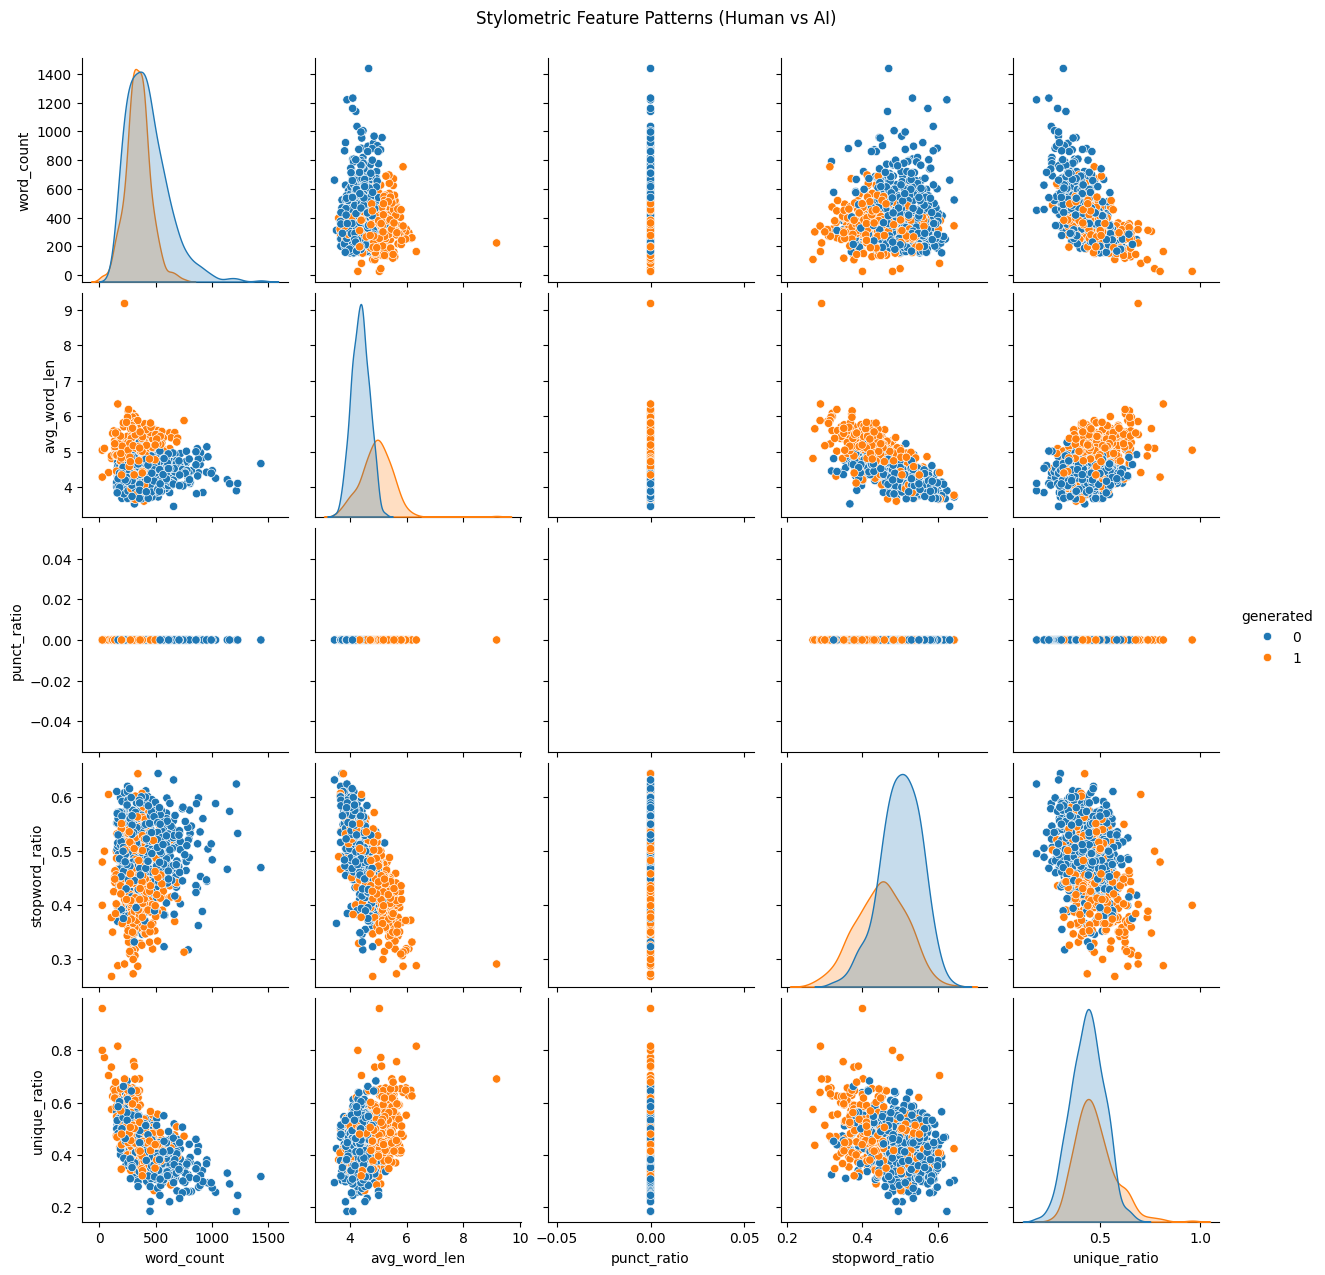

In [5]:
sns.pairplot(df_style.sample(1000), vars=['word_count','avg_word_len','punct_ratio','stopword_ratio','unique_ratio'], hue='generated')
plt.suptitle("Stylometric Feature Patterns (Human vs AI)", y=1.02)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X = df_style['clean_text']
y = df_style['generated']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 390652
Test size: 97664


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Replace NaN or missing text entries with empty strings
X_train = X_train.fillna("")
X_test = X_test.fillna("")

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("✅ TF-IDF shape:", X_train_tfidf.shape)


✅ TF-IDF shape: (390652, 5000)


In [8]:
from scipy.sparse import hstack, csr_matrix

# Stylometric numeric features
num_features = ['word_count', 'avg_word_len', 'punct_ratio', 'stopword_ratio', 'unique_ratio']

X_train_num = df_style.loc[X_train.index, num_features].values
X_test_num = df_style.loc[X_test.index, num_features].values

# Combine both types
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_num)])
X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_num)])

print("Final feature matrix shapes:")
print("Train:", X_train_final.shape)
print("Test :", X_test_final.shape)


Final feature matrix shapes:
Train: (390652, 5005)
Test : (97664, 5005)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_final, y_train)

y_pred_lr = lr.predict(X_test_final)
print("✅ Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))


✅ Logistic Regression Accuracy: 0.9907


In [10]:
import time
from sklearn.ensemble import RandomForestClassifier

start = time.time()
rf = RandomForestClassifier(
    n_estimators=150,      # slightly fewer trees (was 200)
    max_depth=25,          # limits overgrowth, same accuracy range
    min_samples_split=5,   # avoids tiny splits
    max_features='sqrt',   # reduces per-tree feature space
    n_jobs=-1,             # use all CPU cores efficiently
    random_state=42
)
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)
print("✅ Random Forest trained in", round((time.time() - start)/60, 2), "minutes")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))


✅ Random Forest trained in 12.25 minutes
Accuracy: 0.9928


In [11]:
from xgboost import XGBClassifier

start = time.time()
xgb = XGBClassifier(
    n_estimators=250,       # enough for convergence
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,          # random subsampling for speed
    colsample_bytree=0.8,
    tree_method='hist',     # faster on large sparse matrices
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_final, y_train)
y_pred_xgb = xgb.predict(X_test_final)
print("✅ XGBoost trained in", round((time.time() - start)/60, 2), "minutes")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))


✅ XGBoost trained in 7.22 minutes
Accuracy: 0.9972


In [12]:
from sklearn.svm import LinearSVC

start = time.time()
svm = LinearSVC(random_state=42, max_iter=2000)
svm.fit(X_train_final, y_train)
y_pred_svm = svm.predict(X_test_final)
print("✅ SVM trained in", round((time.time() - start)/60, 2), "minutes")
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))


✅ SVM trained in 0.28 minutes
Accuracy: 0.9857


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    roc  = roc_auc_score(y_true, y_pred)
    return [name, acc, prec, rec, f1, roc]

results = [
    evaluate_model("Logistic Regression", y_test, y_pred_lr),
    evaluate_model("Random Forest", y_test, y_pred_rf),
    evaluate_model("XGBoost", y_test, y_pred_xgb),
    evaluate_model("SVM", y_test, y_pred_svm)
]

results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC'])
results_df.sort_values(by='Accuracy', ascending=False)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.997215,0.998569,0.993973,0.996266,0.996562
1,Random Forest,0.992751,0.999414,0.981180,0.990213,0.990418
0,Logistic Regression,0.990672,0.991684,0.983290,0.987469,0.989184
3,SVM,0.985747,0.990227,0.971455,0.980751,0.982866


In [17]:
from sklearn.ensemble import VotingClassifier
import numpy as np, time

start = time.time()
ensemble = VotingClassifier(
    estimators=[('lr', lr), ('xgb', xgb), ('svm', svm)],  # removed RandomForest
    voting='hard'
)

print("🟢 Fitting Ensemble...")
ensemble.fit(X_train_final, y_train)

print("🟢 Predicting in batches...")
batch_size = 20000
y_preds = []
for i in range(0, X_test_final.shape[0], batch_size):
    batch = X_test_final[i:i+batch_size]
    y_batch = ensemble.predict(batch)
    y_preds.extend(y_batch)

y_pred_ens = np.array(y_preds)
print("✅ Ensemble finished in", round((time.time() - start)/60, 2), "minutes")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ens), 4))


🟢 Fitting Ensemble...
🟢 Predicting in batches...
✅ Ensemble finished in 9.09 minutes
Accuracy: 0.9915


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.997215,0.998569,0.993973,0.996266,0.996562
1,Random Forest,0.992751,0.999414,0.981180,0.990213,0.990418
5,Ensemble,0.991491,0.993607,0.983563,0.988560,0.989893
4,Ensemble,0.991491,0.993607,0.983563,0.988560,0.989893
0,Logistic Regression,0.990672,0.991684,0.983290,0.987469,0.989184
3,SVM,0.985747,0.990227,0.971455,0.980751,0.982866



🏆 Best Model: XGBoost


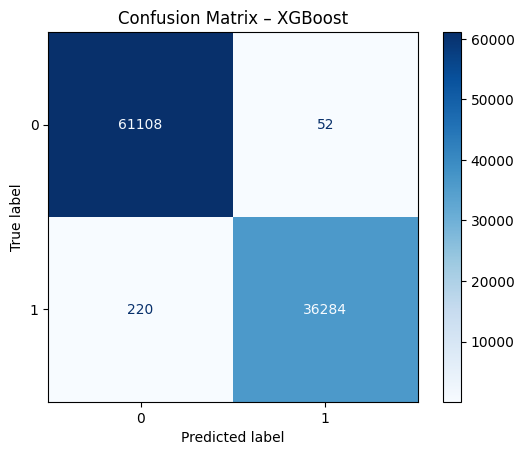

✅ Confusion matrix plotted in 0.33 sec

✅ All models saved in /models/ folder


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import joblib, time, os   # 👈 add os here

# Append ensemble results
results.append(evaluate_model("Ensemble", y_test, y_pred_ens))
results_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC'])
display(results_df.sort_values(by='Accuracy', ascending=False))

# Confusion matrix for best model
best_model_name = results_df.iloc[results_df['Accuracy'].idxmax()]['Model']
print("\n🏆 Best Model:", best_model_name)

best_estimator = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'SVM': svm,
    'Ensemble': ensemble
}[best_model_name]

start = time.time()
ConfusionMatrixDisplay.from_estimator(best_estimator, X_test_final, y_test, cmap='Blues')
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()
print("✅ Confusion matrix plotted in", round((time.time() - start), 2), "sec")

# Save all trained models
os.makedirs("../models", exist_ok=True)
joblib.dump(lr, "../models/logistic_reg.pkl")
joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(xgb, "../models/xgboost.pkl")
joblib.dump(svm, "../models/svm.pkl")
joblib.dump(ensemble, "../models/ensemble.pkl")

print("\n✅ All models saved in /models/ folder")
